# Trabalho Prático 1: Compressão de Imagens

## Alunos: 

- Felipe Eduardo dos Santos - 2017021223
- Renan Antunes Braga Bomtempo - 2018048524

# Introdução

Falar o que a gente implementou e das decisões que 
tomamos sobre a medição de tamanho de arquivo etc

# Dependências

In [1]:
%matplotlib inline
import cv2
import io
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import fftpack
import matplotlib.image as mpimg

np.set_printoptions(precision=1, suppress=True)

# Funções Auxiliares

In [2]:
def get_2D_dct(img):
    """ Get 2D Cosine Transform of Image
    """
    return fftpack.dct(fftpack.dct(img.T, norm='ortho').T, norm='ortho')

def get_2d_idct(coefficients):
    """ Get 2D Inverse Cosine Transform of Image
    """
    return fftpack.idct(fftpack.idct(coefficients.T, norm='ortho').T, norm='ortho')

# Calcula o rmse
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

# Calcula o psnr
def psnr(predictions, targets):
    rmsev = rmse(predictions, targets)
    return 20 * np.log10(255/rmsev)

# Retorna o tamanho de um arquivo em bytes
def file_size(file_path):
    if os.path.isfile(file_path):
        file_info = os.stat(file_path)
        return file_info.st_size

# Printa a imagem em tons de cinza (0-255)
def print_gimage(img, window_name):
    #plt.subplot(121)
    plt.imshow(img, cmap = 'gray', clim=(0, 255))
    plt.title(window_name+" - "+str(img.shape)), plt.xticks([]), plt.yticks([])
    plt.show()

# Printa a imagem em tons de cinza (-128, 127)
def print_sgimage(img, window_name):
    #plt.subplot(121)
    plt.imshow(img, cmap = 'gray', clim=(-128, 127))
    plt.title(window_name+" - "+str(img.shape)), plt.xticks([]), plt.yticks([])
    plt.show()

# Salva um numpy.ndarray, com elementos do tipo numpy.uint8
# em um arquivo, seja .txt ou .bin
def img_to_file(img,output_name,separator=""):
    file = open(output_name, "w")
    img.tofile(file,sep=separator)
    file.close()

# De um arquivo txt ou bin, lê um numpy.ndarray de dimenções
# shape(tupla)
def file_to_img(input_name,separator=""):
    file = open(input_name,"r")
    img = np.fromfile(file,dtype = np.int8,sep=separator)
    #img = img.reshape(shape)
    file.close()
    return img
    

# Abrindo a Imagem

Atribua a variavel "input_img_name" o nome da imagem a ser comprimida

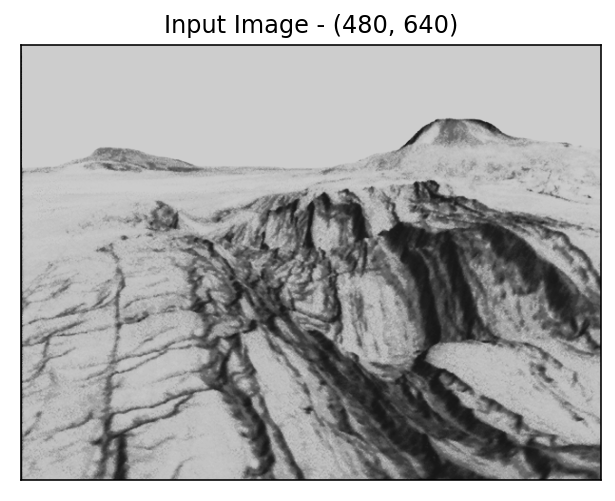

In [3]:
# Nome do arquivo de imagem a ser comprimida
input_img_name = "11.pgm"

# Carrega a imagem como um numpy.ndarray, com elementos do tipo numpy.uint8
img = cv2.imread(input_img_name,0)

# Mostra imagem que foi carregada
print_gimage(img,'Input Image')

# Compressão

### Transfomada

Aplicamos a DCT em blocos 8x8 da imagem

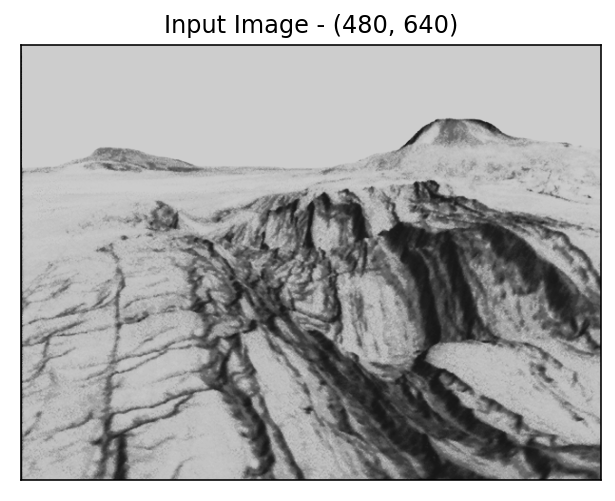

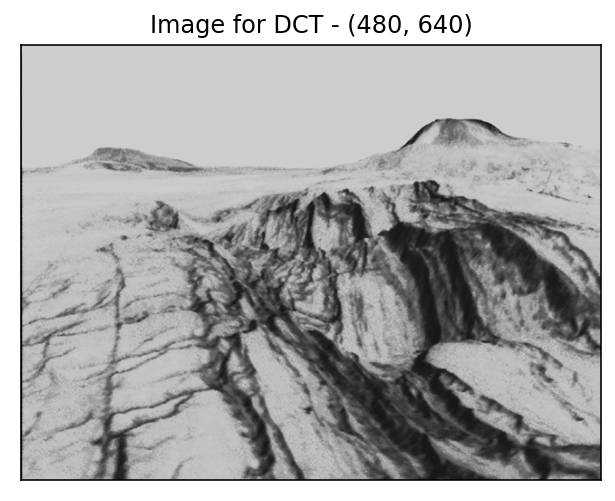

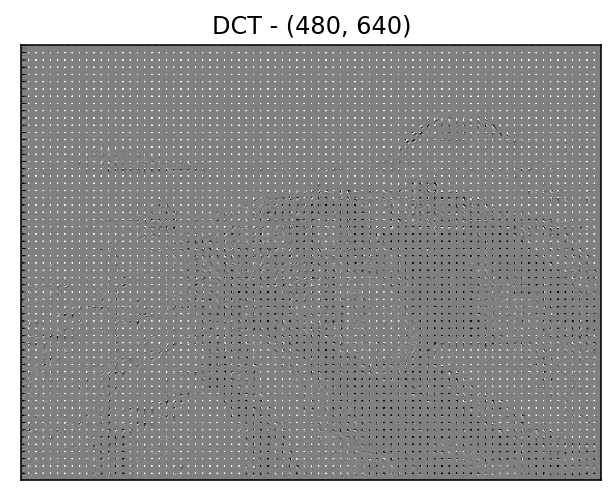

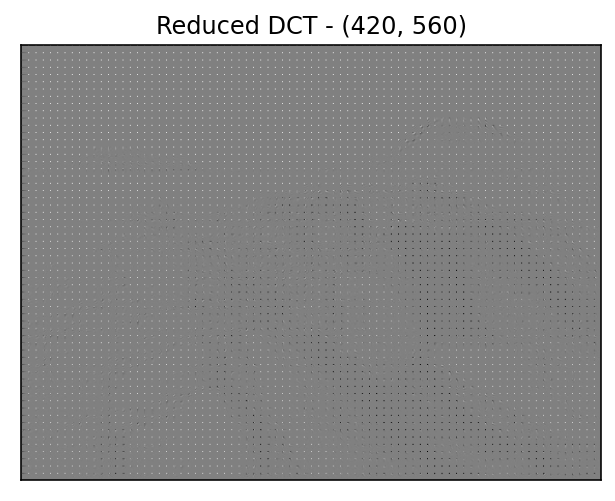

Compressão da DCT reduzida: 23.4375


In [4]:
#image = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)

# Parâmetros da transformada
step    = 8     # Tamanho do bloco DCT
sv_step = 7    # Tamanho do bloco a ser salvo
dif     = step - sv_step

# Tamanho da imagem original
orig_size = img.shape

# Tamanho da DCT, aplicando padding se necessário
dct_size = (orig_size[0]+(step-(orig_size[0]%step))%step,
            orig_size[1]+(step-(orig_size[1]%step))%step)

# Tamanho da DCT reduzida
redu_size = (dct_size[0]-(dif*dct_size[0]//step),
             dct_size[1]-(dif*dct_size[1]//step))

# Matriz da DCT completa
DCT = np.zeros(dct_size, dtype=np.float)

# Matriz da DCT apenas com os valores relevantes
reduced_DCT = np.zeros(redu_size, dtype=np.float)

# Imagem em que a DCT será aplicada
dct_img = np.zeros(dct_size, dtype=np.float)
dct_img[:orig_size[0], :orig_size[1]] = (img.astype(float))-128

# Executa a DCT
for y in range(0,dct_size[0],step):
    for x in range(0,dct_size[1],step):
        dct_step = get_2D_dct(dct_img[y:y+step, x:x+step])
        # DCT completa
        DCT[y:y+step, x:x+step] = dct_step
        # DCT reduzida
        reduced_DCT[y*sv_step//step:y*sv_step//step+sv_step,
                    x*sv_step//step:x*sv_step//step+sv_step] = dct_step[:sv_step,:sv_step]

# Aplica quantização na matriz reduzida da DCT
# normalizando os valores para o intervalo [-128, 127]
Q = np.max(np.absolute(reduced_DCT))/127 #Valor de quantização
reduced_DCT = reduced_DCT/Q

# Converte a matriz para inteiro de 8bits para armazenamento
# (o que serve como maneira de arrendondar os valores da transormada)
reduced_DCT = reduced_DCT.astype(np.int8)

# Visualização dos resultados
print_gimage(img,"Input Image")
print_sgimage(dct_img, "Image for DCT")
print_sgimage(DCT,"DCT")
print_sgimage(reduced_DCT,"Reduced DCT")

# Calcular compressão da DCT reduzida
print("Compressão da DCT reduzida:",100-(reduced_DCT.size/img.size)*100)

### Codificação

Implementamos o algoritmo de comprimento por corrida para os zeros, que normalmente tem alta frequência

In [43]:
# Transformando a o DCT reduzido em um array unidimencional
dct_arr = np.asarray(reduced_DCT).reshape(-1)

# Array codificado
cod_arr = []

# Loop para gerar o array com os comprimentos de corrida dos zeros
i=0
while i < len(dct_arr):
    if (dct_arr[i]!=0):
        cod_arr.append(dct_arr[i])
        i+=1
    else:
        count=1
        while(i+count<len(dct_arr) and count<127 and dct_arr[i+count]==0):
            count+=1
        cod_arr.append(0)
        cod_arr.append(count)
        i+=count


header = [np.int8(orig_size[0]>>8),np.int8(orig_size[0]),np.int8(orig_size[1]>>8),np.int8(orig_size[1]),np.int8(Q),(step,sv_step]
cod_arr = header.extend(cod_arr)

cod_arr = np.array(cod_arr,dtype = np.int8)

# Calculr a compressão do comprimento de corrida aplicado
print("Compressão do comprimento de corrida:",100-len(cod_arr)/len(dct_arr)*100)
print("len coded array:",len(cod_arr))

TypeError: int() argument must be a string, a bytes-like object or a number, not 'NoneType'

### Resultado da compressão

Salvar no arquivo e comparar o tamanho com a imagem original

In [6]:
img_to_file(img,"original.bin")
img_to_file(cod_arr,"coded_compressed.bin")

print("Compressão de ",(100-(file_size("coded_compressed.bin")/file_size("original.bin"))*100), "%")

Compressão de  58.513671875 %


# Decompressão

### Decodificação

Ler do arquivo e decodificar pra ter os coeficientes da transformada de volta

In [7]:
# Arquivo comprimido
arq_arr = file_to_img("coded_compressed.bin")

# Array decodificado
decod_arr = []

# Decodifica o arquivo de bytes gerado pela compressão
i=0
while i < len(arq_arr):
    if arq_arr[i] != 0:
        decod_arr.append(arq_arr[i])
        if (i == len(arq_arr)-2):
            decod_arr.append(arq_arr[i+1])
    else:
        for j in range(arq_arr[i+1]):
            decod_arr.append(0)
        i+=1
    i+=1
decoded_arr = np.array(decod_arr,dtype = np.int8)

# Tamanho da imagem original armazenado no header
# orig_size = 

# DCT reduzida obtida na decodificação
reduced_DCT = decoded_arr.reshape(redu_size)

### Transformada Inversa

Com os coeficientes decodificados, aplicar a transformada inversa

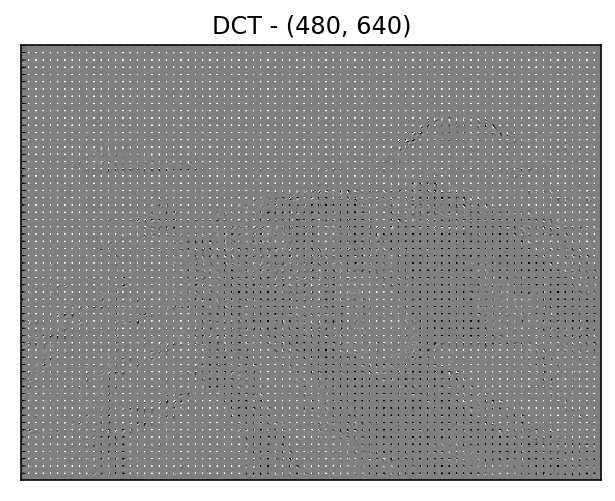

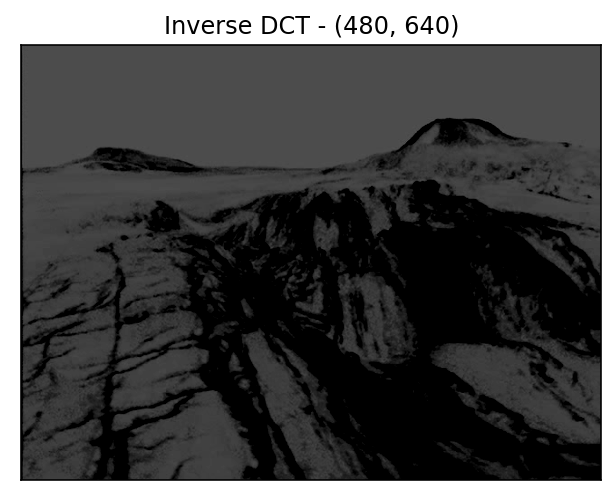

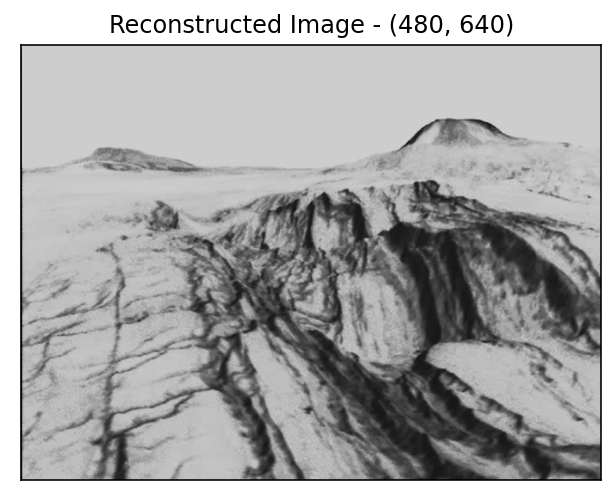

In [32]:
# Tamanho da DCT, aplicando padding se necessário
dct_size = (orig_size[0]+(step-(orig_size[0]%step))%step,
            orig_size[1]+(step-(orig_size[1]%step))%step)

# Tamanho da DCT reduzida
redu_size = reduced

dct = np.zeros(dct_size, dtype=np.float)
inverse_dct  = np.zeros(dct_size, dtype=np.float)

# Extendendo a DCT reduzida para o tamanho original da DCT
for y in range(0,redu_size[0],sv_step):
    for x in range(0,redu_size[1],sv_step):
        block = np.zeros((step,step),dtype=np.float)
        block[:sv_step, :sv_step] = reduced_DCT[y:y+sv_step, x:x+sv_step]
        dct[y+(dif*y//sv_step):y+(dif*y//sv_step)+step,
            x+(dif*x//sv_step):x+(dif*x//sv_step)+step] = block

# Reverte a quatização
dct = Q*dct

# Transformada inversa
for y in range(0,dct_size[0],step):
    for x in range(0,dct_size[1],step):
        block = get_2d_idct(dct[y:y+step, x:x+step])
        inverse_dct[y:y+step, x:x+step] = block

# Imagem reconstruida
reco_img = inverse_dct[:orig_size[0], :orig_size[1]]+128

print_sgimage(dct,"DCT")
print_sgimage(inverse_dct,"Inverse DCT")
print_gimage(reco_img, "Reconstructed Image")

# Salvar imagens em .pgm
mpimg.imsave("{0}.png".format(input_img_name), img, 0, 255, cmap='gray')
mpimg.imsave(("{0}_IDCT_{1}x{1}-{2}.png".format(input_img_name,step, sv_step)), reco_img, 0, 255, cmap='gray')


# Analise de resultados

Printar o PSNR e falar algo sobre nosso resultados

In [9]:
print("PSNR foi de:",psnr(img,reco_img))

PSNR foi de: 39.1926446274516


In [10]:
a = [1,2,3]
b = [5,5,5]
b.extend(a)
print(b)

[5, 5, 5, 1, 2, 3]
